# Домашнее задание №4. Симуляция распространения болезни с NetworkX

## Цель работы

Смоделировать распространение инфекционного заболевания в сети аэропортов США с использованием SI-модели и проанализировать связь скорости распространения инфекции со структурными характеристиками графа аэропортов.

В работе будут выполнены:

1. подготовка данных об авиаперелётах;
2. реализация SI-модели распространения инфекции;
3. исследование влияния вероятности заражения на скорость распространения;
4. построение графа аэропортов с помощью NetworkX;
5. расчёт сетевых характеристик аэропортов;
6. анализ связи между характеристиками графа и временем заражения.

## Данные

Источник: [US Flights Data 2008 (Kaggle)](https://www.kaggle.com/datasets/vikalpdongre/us-flights-data-2008).

Исходный файл `2008.csv` имеет большой размер и не хранится в Git-репозитории. Для воспроизведения работы его необходимо скачать и поместить в `hw04_networkx_disease/data/2008.csv` (или `hw04_networkx_disease/data/2008.zip`).


## 0. Импорт библиотек и настройки

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Библиотеки успешно импортированы.")
print(f"pandas:   {pd.__version__}")
print(f"numpy:    {np.__version__}")
print(f"networkx: {nx.__version__}")

Библиотеки успешно импортированы.
pandas:   3.0.5
numpy:    2.5.2
networkx: 3.6.1


## 1. Загрузка и первичный анализ данных

Сначала определим расположение набора данных и загрузим только те столбцы, которые необходимы для моделирования распространения инфекции и построения графа аэропортов.

In [2]:
# Ноутбук может запускаться как из папки hw04_networkx_disease,
# так и из корня репозитория. Проверяем оба варианта.
data_dir_candidates = [
    Path("data"),
    Path("hw04_networkx_disease") / "data",
]

DATA_DIR = next(
    (
        candidate
        for candidate in data_dir_candidates
        if candidate.exists()
    ),
    data_dir_candidates[0],
)

csv_path = DATA_DIR / "2008.csv"
zip_path = DATA_DIR / "2008.zip"

if csv_path.exists():
    DATA_PATH = csv_path
elif zip_path.exists():
    DATA_PATH = zip_path
else:
    raise FileNotFoundError(
        "Не найден датасет 2008.csv/2008.zip. "
        "Скачайте US Flights Data 2008 с Kaggle и поместите файл "
        "в hw04_networkx_disease/data/."
    )

print("Используем файл:")
print(DATA_PATH)

print("\nРазмер файла:")
print(f"{DATA_PATH.stat().st_size / 1024**2:.2f} МБ")


Используем файл:
data\2008.csv

Размер файла:
657.48 МБ


In [3]:
df_preview = pd.read_csv(
    DATA_PATH,
    nrows=5,
    compression="infer"
)

print("Количество столбцов:", len(df_preview.columns))

print("\nНазвания столбцов:")
print(df_preview.columns.tolist())

print("\nПервые строки:")
display(df_preview)

Количество столбцов: 29

Названия столбцов:
['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

Первые строки:


,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2008,1,3,4,2003,1955,2211,2225,WN,335,N712SW,128,150,116,-14,8,IAD,TPA,810,4,8,0,NaN,0,NaN,NaN,NaN,NaN,NaN
1,2008,1,3,4,754,735,1002,1000,WN,3231,N772SW,128,145,113,2,19,IAD,TPA,810,5,10,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,2008,1,3,4,628,620,804,750,WN,448,N428WN,96,90,76,14,8,IND,BWI,515,3,17,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3,2008,1,3,4,926,930,1054,1100,WN,1746,N612SW,88,90,78,-6,-4,IND,BWI,515,3,7,0,NaN,0,NaN,NaN,NaN,NaN,NaN
4,2008,1,3,4,1829,1755,1959,1925,WN,3920,N464WN,90,90,77,34,34,IND,BWI,515,3,10,0,NaN,0,2.0,0.0,0.0,0.0,32.0


In [4]:
month_counts = (
    pd.read_csv(
        DATA_PATH,
        usecols=["Month"],
        compression="infer"
    )["Month"]
    .value_counts()
    .sort_index()
)

print("=" * 60)
print("КОЛИЧЕСТВО РЕЙСОВ ПО МЕСЯЦАМ")
print("=" * 60)

display(month_counts)

print(f"\nКоличество различных месяцев: {month_counts.size}")
print(f"Всего записей: {month_counts.sum():,}")

КОЛИЧЕСТВО РЕЙСОВ ПО МЕСЯЦАМ


Month
1     605765
2     569236
3     616090
4     598126
5     606293
6     608665
7     627931
8     612279
9     540908
10    556205
11    523272
12    544958
Name: count, dtype: int64


Количество различных месяцев: 12
Всего записей: 7,009,728


### Выбор периода для моделирования

В исходном файле содержатся данные о перелётах за 2008 год. Согласно условию домашнего задания, моделирование должно проводиться на данных за один месяц, поэтому для дальнейшего анализа будет выбран один календарный месяц.

In [5]:
required_columns = [
    "Year",
    "Month",
    "DayofMonth",
    "DepTime",
    "ArrTime",
    "Origin",
    "Dest",
    "Cancelled",
    "Diverted",
]

df_check = pd.read_csv(
    DATA_PATH,
    usecols=required_columns,
    nrows=100_000,
    compression="infer"
)

print("=" * 60)
print("ПРОВЕРКА НЕОБХОДИМЫХ ПРИЗНАКОВ")
print("=" * 60)

print("\nРазмер тестовой выборки:")
print(df_check.shape)

print("\nТипы данных:")
display(df_check.dtypes.to_frame("dtype"))

print("\nКоличество пропусков:")
display(
    df_check
    .isna()
    .sum()
    .to_frame("missing")
)

print("\nПервые 10 строк:")
display(df_check.head(10))

ПРОВЕРКА НЕОБХОДИМЫХ ПРИЗНАКОВ

Размер тестовой выборки:
(100000, 9)

Типы данных:


,dtype
Year,int64
Month,int64
DayofMonth,int64
DepTime,float64
ArrTime,float64
Origin,str
Dest,str
Cancelled,int64
Diverted,int64



Количество пропусков:


,missing
Year,0
Month,0
DayofMonth,0
DepTime,1142
ArrTime,1302
Origin,0
Dest,0
Cancelled,0
Diverted,0



Первые 10 строк:


,Year,Month,DayofMonth,DepTime,ArrTime,Origin,Dest,Cancelled,Diverted
0,2008,1,3,2003.0,2211.0,IAD,TPA,0,0
1,2008,1,3,754.0,1002.0,IAD,TPA,0,0
2,2008,1,3,628.0,804.0,IND,BWI,0,0
3,2008,1,3,926.0,1054.0,IND,BWI,0,0
4,2008,1,3,1829.0,1959.0,IND,BWI,0,0
5,2008,1,3,1940.0,2121.0,IND,JAX,0,0
6,2008,1,3,1937.0,2037.0,IND,LAS,0,0
7,2008,1,3,1039.0,1132.0,IND,LAS,0,0
8,2008,1,3,617.0,652.0,IND,MCI,0,0
9,2008,1,3,1620.0,1639.0,IND,MCI,0,0


In [6]:
origins = set(df_check["Origin"].dropna().unique())
destinations = set(df_check["Dest"].dropna().unique())
airports_preview = origins | destinations

print("=" * 60)
print("ПРЕДВАРИТЕЛЬНАЯ ПРОВЕРКА АЭРОПОРТОВ")
print("=" * 60)

print(f"Уникальных аэропортов в первых 100 000 строках: {len(airports_preview)}")

print("\nПримеры кодов аэропортов:")
print(sorted(airports_preview)[:30])

ПРЕДВАРИТЕЛЬНАЯ ПРОВЕРКА АЭРОПОРТОВ
Уникальных аэропортов в первых 100 000 строках: 90

Примеры кодов аэропортов:
['ABQ', 'ALB', 'AMA', 'ATL', 'AUS', 'BDL', 'BFL', 'BHM', 'BNA', 'BOI', 'BTR', 'BUF', 'BUR', 'BWI', 'CHS', 'CLE', 'CLT', 'CMH', 'COS', 'CRP', 'CRW', 'DAL', 'DAY', 'DCA', 'DEN', 'DTW', 'ELP', 'EUG', 'EWR', 'FAT']


### Подготовка данных за январь 2008 года

Исходный файл содержит данные за весь 2008 год. Для моделирования выбран январь 2008 года.

Для симуляции необходимы только фактически выполненные рейсы. Отменённые и перенаправленные рейсы исключаются из анализа.

Момент вылета используется для определения того, был ли аэропорт отправления заражён к моменту отправления самолёта. Время прибытия рассчитывается как время вылета плюс фактическая продолжительность рейса (`ActualElapsedTime`).

In [7]:
columns_for_simulation = [
    "Year",
    "Month",
    "DayofMonth",
    "DepTime",
    "ActualElapsedTime",
    "Origin",
    "Dest",
    "Cancelled",
    "Diverted",
]

chunks = []

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=columns_for_simulation,
    chunksize=500_000,
    compression="infer",
):
    january_chunk = chunk[chunk["Month"] == 1]

    if not january_chunk.empty:
        chunks.append(january_chunk)

january_flights = pd.concat(
    chunks,
    ignore_index=True
)

print("=" * 60)
print("ДАННЫЕ ЗА ЯНВАРЬ 2008")
print("=" * 60)

print(f"Количество записей: {len(january_flights):,}")
print(f"Количество столбцов: {january_flights.shape[1]}")

display(january_flights.head())

ДАННЫЕ ЗА ЯНВАРЬ 2008
Количество записей: 605,765
Количество столбцов: 9


,Year,Month,DayofMonth,DepTime,ActualElapsedTime,Origin,Dest,Cancelled,Diverted
0,2008,1,3,2003.0,128.0,IAD,TPA,0,0
1,2008,1,3,754.0,128.0,IAD,TPA,0,0
2,2008,1,3,628.0,96.0,IND,BWI,0,0
3,2008,1,3,926.0,88.0,IND,BWI,0,0
4,2008,1,3,1829.0,90.0,IND,BWI,0,0


In [8]:
flights = january_flights.copy()

rows_before = len(flights)

flights = flights[
    (flights["Cancelled"] == 0)
    & (flights["Diverted"] == 0)
    & flights["DepTime"].notna()
    & flights["ActualElapsedTime"].notna()
    & flights["Origin"].notna()
    & flights["Dest"].notna()
].copy()

flights = flights[
    flights["Origin"] != flights["Dest"]
].copy()

rows_after = len(flights)

print("=" * 60)
print("ОЧИСТКА ДАННЫХ")
print("=" * 60)

print(f"Записей до очистки:    {rows_before:,}")
print(f"Записей после очистки: {rows_after:,}")
print(f"Удалено записей:       {rows_before - rows_after:,}")
print(
    f"Доля сохранённых рейсов: "
    f"{rows_after / rows_before * 100:.2f}%"
)

ОЧИСТКА ДАННЫХ
Записей до очистки:    605,765
Записей после очистки: 587,130
Удалено записей:       18,635
Доля сохранённых рейсов: 96.92%


In [9]:
dep_time_int = flights["DepTime"].astype(int)

hours = dep_time_int // 100
minutes = dep_time_int % 100

valid_time_mask = (
    (minutes >= 0)
    & (minutes < 60)
    & (hours >= 0)
    & (hours <= 24)
    & ~((hours == 24) & (minutes != 0))
)

invalid_times = (~valid_time_mask).sum()

print(f"Некорректных значений DepTime: {invalid_times}")

flights = flights.loc[valid_time_mask].copy()

dep_time_int = flights["DepTime"].astype(int)

flights["departure_minutes"] = (
    (dep_time_int // 100) * 60
    + (dep_time_int % 100)
)

display(
    flights[
        ["DayofMonth", "DepTime", "departure_minutes"]
    ].head(10)
)

Некорректных значений DepTime: 0


,DayofMonth,DepTime,departure_minutes
0,3,2003.0,1203
1,3,754.0,474
2,3,628.0,388
3,3,926.0,566
4,3,1829.0,1109
5,3,1940.0,1180
6,3,1937.0,1177
7,3,1039.0,639
8,3,617.0,377
9,3,1620.0,980


In [10]:
base_dates = pd.to_datetime(
    {
        "year": flights["Year"],
        "month": flights["Month"],
        "day": flights["DayofMonth"],
    }
)

flights["departure_time"] = (
    base_dates
    + pd.to_timedelta(
        flights["departure_minutes"],
        unit="m"
    )
)

flights["arrival_time"] = (
    flights["departure_time"]
    + pd.to_timedelta(
        flights["ActualElapsedTime"],
        unit="m"
    )
)

flights = (
    flights
    .sort_values("departure_time")
    .reset_index(drop=True)
)

print("=" * 60)
print("ВРЕМЕННАЯ ШКАЛА РЕЙСОВ")
print("=" * 60)

print(
    "Первый вылет:",
    flights["departure_time"].min()
)

print(
    "Последний вылет:",
    flights["departure_time"].max()
)

print(
    "Последнее прибытие:",
    flights["arrival_time"].max()
)

display(
    flights[
        [
            "Origin",
            "Dest",
            "departure_time",
            "arrival_time",
            "ActualElapsedTime",
        ]
    ].head(10)
)

ВРЕМЕННАЯ ШКАЛА РЕЙСОВ
Первый вылет: 2008-01-01 00:01:00
Последний вылет: 2008-02-01 00:00:00
Последнее прибытие: 2008-02-01 08:16:00


,Origin,Dest,departure_time,arrival_time,ActualElapsedTime
0,MDW,MCI,2008-01-01 00:01:00,2008-01-01 01:17:00,76.0
1,MDW,BWI,2008-01-01 00:01:00,2008-01-01 01:28:00,87.0
2,ATL,CHS,2008-01-01 00:02:00,2008-01-01 00:57:00,55.0
3,DEN,FLL,2008-01-01 00:02:00,2008-01-01 03:29:00,207.0
4,PDX,JFK,2008-01-01 00:02:00,2008-01-01 05:36:00,334.0
5,OAK,IAD,2008-01-01 00:03:00,2008-01-01 04:48:00,285.0
6,CLE,SAT,2008-01-01 00:03:00,2008-01-01 03:30:00,207.0
7,MDW,TPA,2008-01-01 00:03:00,2008-01-01 02:23:00,140.0
8,LAS,SAN,2008-01-01 00:04:00,2008-01-01 01:10:00,66.0
9,SLC,ATL,2008-01-01 00:04:00,2008-01-01 03:19:00,195.0


In [11]:
airports = sorted(
    set(flights["Origin"])
    | set(flights["Dest"])
)

print("=" * 60)
print("АЭРОПОРТЫ В СЕТИ")
print("=" * 60)

print(
    f"Количество уникальных аэропортов: "
    f"{len(airports)}"
)

print("\nПервые 30 кодов аэропортов:")
print(airports[:30])

АЭРОПОРТЫ В СЕТИ
Количество уникальных аэропортов: 286

Первые 30 кодов аэропортов:
['ABE', 'ABI', 'ABQ', 'ABY', 'ACT', 'ACV', 'ACY', 'ADK', 'ADQ', 'AEX', 'AGS', 'ALB', 'ALO', 'AMA', 'ANC', 'ASE', 'ATL', 'ATW', 'AUS', 'AVL', 'AVP', 'AZO', 'BDL', 'BET', 'BFL', 'BGM', 'BGR', 'BHM', 'BIL', 'BIS']


In [12]:
START_AIRPORT = "ABE"

print("=" * 60)
print("ПРОВЕРКА СТАРТОВОГО АЭРОПОРТА")
print("=" * 60)

print(
    f"Аэропорт {START_AIRPORT} присутствует в сети:",
    START_AIRPORT in airports
)

departures_from_start = (
    flights["Origin"] == START_AIRPORT
).sum()

arrivals_to_start = (
    flights["Dest"] == START_AIRPORT
).sum()

print(
    f"Вылетов из {START_AIRPORT}: "
    f"{departures_from_start:,}"
)

print(
    f"Прилётов в {START_AIRPORT}: "
    f"{arrivals_to_start:,}"
)

ПРОВЕРКА СТАРТОВОГО АЭРОПОРТА
Аэропорт ABE присутствует в сети: True
Вылетов из ABE: 383
Прилётов в ABE: 391


In [13]:
print("=" * 70)
print("ИТОГОВЫЙ ДАТАСЕТ ДЛЯ СИМУЛЯЦИИ")
print("=" * 70)

print(f"Количество рейсов:     {len(flights):,}")
print(f"Количество аэропортов: {len(airports)}")

print(
    f"Период: "
    f"{flights['departure_time'].min()} "
    f"— "
    f"{flights['arrival_time'].max()}"
)

print("\nПропуски:")

display(
    flights[
        [
            "Origin",
            "Dest",
            "departure_time",
            "arrival_time",
        ]
    ]
    .isna()
    .sum()
    .to_frame("missing")
)

print("\nПервые строки итогового набора:")

display(
    flights[
        [
            "Origin",
            "Dest",
            "departure_time",
            "arrival_time",
        ]
    ].head()
)

ИТОГОВЫЙ ДАТАСЕТ ДЛЯ СИМУЛЯЦИИ
Количество рейсов:     587,130
Количество аэропортов: 286
Период: 2008-01-01 00:01:00 — 2008-02-01 08:16:00

Пропуски:


,missing
Origin,0
Dest,0
departure_time,0
arrival_time,0



Первые строки итогового набора:


,Origin,Dest,departure_time,arrival_time
0,MDW,MCI,2008-01-01 00:01:00,2008-01-01 01:17:00
1,MDW,BWI,2008-01-01 00:01:00,2008-01-01 01:28:00
2,ATL,CHS,2008-01-01 00:02:00,2008-01-01 00:57:00
3,DEN,FLL,2008-01-01 00:02:00,2008-01-01 03:29:00
4,PDX,JFK,2008-01-01 00:02:00,2008-01-01 05:36:00


## 2. Часть 1. Симуляция распространения инфекции

Используется SI-модель (Susceptible-Infected), в которой каждый аэропорт находится в одном из двух состояний:

- **Susceptible (S)** — здоровый;
- **Infected (I)** — заражённый.

В начале симуляции заражён только стартовый аэропорт Allentown (`ABE`).

Для каждого рейса в хронологическом порядке проверяется состояние аэропорта отправления на момент вылета. Если аэропорт уже был заражён, рейс считается потенциально заразным. В этом случае аэропорт назначения заражается с вероятностью `p`.

Моментом заражения аэропорта назначения считается время прибытия заразного рейса.

Так как несколько аэропортов теоретически могут заразиться в одну и ту же минуту, внутри алгоритма отдельно хранится точное время заражения каждого аэропорта. Итоговый результат представляется словарём, где ключом является время заражения, а значением — код аэропорта.

In [14]:
simulation_flights = (
    flights[
        [
            "Origin",
            "Dest",
            "departure_time",
            "arrival_time",
        ]
    ]
    .sort_values("departure_time")
    .reset_index(drop=True)
)

print("=" * 70)
print("ДАННЫЕ ДЛЯ SI-СИМУЛЯЦИИ")
print("=" * 70)

print(f"Количество рейсов: {len(simulation_flights):,}")

print(
    "Начало наблюдения:",
    simulation_flights["departure_time"].min()
)

print(
    "Конец наблюдения:",
    simulation_flights["arrival_time"].max()
)

display(simulation_flights.head())

ДАННЫЕ ДЛЯ SI-СИМУЛЯЦИИ
Количество рейсов: 587,130
Начало наблюдения: 2008-01-01 00:01:00
Конец наблюдения: 2008-02-01 08:16:00


,Origin,Dest,departure_time,arrival_time
0,MDW,MCI,2008-01-01 00:01:00,2008-01-01 01:17:00
1,MDW,BWI,2008-01-01 00:01:00,2008-01-01 01:28:00
2,ATL,CHS,2008-01-01 00:02:00,2008-01-01 00:57:00
3,DEN,FLL,2008-01-01 00:02:00,2008-01-01 03:29:00
4,PDX,JFK,2008-01-01 00:02:00,2008-01-01 05:36:00


In [15]:
def simulate_infection(
    start_airport,
    p,
    flights_df=simulation_flights,
    seed=None,
):
    """
    Выполняет одну SI-симуляцию распространения инфекции
    по сети авиаперелётов.

    Parameters
    ----------
    start_airport : str
        Код аэропорта, в котором инфекция присутствует
        в начале симуляции.

    p : float
        Вероятность заражения аэропорта назначения
        при прилёте самолёта из заражённого аэропорта.

    flights_df : pandas.DataFrame
        Таблица рейсов, отсортированная по времени вылета.

    seed : int or None
        Seed генератора случайных чисел для воспроизводимости.

    Returns
    -------
    dict
        Словарь:
        ключ   -> время заражения,
        значение -> код заражённого аэропорта.
    """

    if not 0 <= p <= 1:
        raise ValueError(
            "Вероятность заражения p должна находиться "
            "в диапазоне [0, 1]."
        )

    all_airports = (
        set(flights_df["Origin"])
        | set(flights_df["Dest"])
    )

    if start_airport not in all_airports:
        raise ValueError(
            f"Аэропорт {start_airport} отсутствует в данных."
        )

    rng = np.random.default_rng(seed)

    simulation_start = flights_df["departure_time"].min()

    # Внутреннее представление:
    # аэропорт -> фактическое время его заражения.
    infection_times = {
        start_airport: simulation_start
    }

    for flight in flights_df.itertuples(index=False):

        origin = flight.Origin
        dest = flight.Dest

        departure_time = flight.departure_time
        arrival_time = flight.arrival_time

        # Проверяем, заражён ли аэропорт отправления
        # к моменту вылета самолёта.
        origin_infection_time = infection_times.get(origin)

        if origin_infection_time is None:
            continue

        if origin_infection_time > departure_time:
            continue

        # Если аэропорт назначения уже заражён
        # к моменту прибытия этого рейса,
        # повторное заражение не требуется.
        dest_infection_time = infection_times.get(dest)

        if (
            dest_infection_time is not None
            and dest_infection_time <= arrival_time
        ):
            continue

        # Попытка заражения.
        if rng.random() < p:
            infection_times[dest] = arrival_time

    # Согласно условию задания результат должен иметь вид:
    # время заражения -> аэропорт.
    #
    # Если два аэропорта заразились в абсолютно одинаковое время,
    # добавляем минимальное смещение в 1 нс только для сохранения
    # уникальности ключей словаря.
    infection_history = {}

    for airport, infection_time in sorted(
        infection_times.items(),
        key=lambda item: item[1],
    ):
        event_time = infection_time

        while event_time in infection_history:
            event_time += pd.Timedelta(nanoseconds=1)

        infection_history[event_time] = airport

    return infection_history

In [18]:
test_simulation = simulate_infection(
    start_airport=START_AIRPORT,
    p=0.5,
    seed=RANDOM_STATE,
)

print("=" * 70)
print("ТЕСТОВАЯ SI-СИМУЛЯЦИЯ")
print("=" * 70)

print(f"Стартовый аэропорт: {START_AIRPORT}")
print("Вероятность заражения: 0.5")

print(
    f"Заражено аэропортов: "
    f"{len(test_simulation)} из {len(airports)}"
)

print(
    f"Доля заражённых: "
    f"{len(test_simulation) / len(airports) * 100:.2f}%"
)

print("\nПервые 15 заражений:")

for infection_time, airport in list(
    test_simulation.items()
)[:15]:
    print(
        f"{infection_time} -> {airport}"
    )

ТЕСТОВАЯ SI-СИМУЛЯЦИЯ
Стартовый аэропорт: ABE
Вероятность заражения: 0.5
Заражено аэропортов: 286 из 286
Доля заражённых: 100.00%

Первые 15 заражений:
2008-01-01 00:01:00 -> ABE
2008-01-01 10:17:00 -> ORD
2008-01-01 11:41:00 -> MCI
2008-01-01 11:46:00 -> GRR
2008-01-01 11:55:00 -> DAY
2008-01-01 12:07:00 -> CVG
2008-01-01 12:19:00 -> FAR
2008-01-01 12:23:00 -> SGF
2008-01-01 12:23:00.000000001 -> IND
2008-01-01 12:25:00 -> DCA
2008-01-01 12:44:00 -> ATL
2008-01-01 12:45:00 -> LEX
2008-01-01 12:45:00.000000001 -> RDU
2008-01-01 12:53:00 -> EWR
2008-01-01 12:54:00 -> SDF


In [19]:
print("=" * 70)
print("ПОСЛЕДНИЕ ЗАРАЖЕНИЯ")
print("=" * 70)

for infection_time, airport in list(
    test_simulation.items()
)[-15:]:
    print(
        f"{infection_time} -> {airport}"
    )

first_infection_time = min(test_simulation.keys())
last_infection_time = max(test_simulation.keys())

infection_duration = (
    last_infection_time
    - first_infection_time
)

print("\nПродолжительность распространения:")
print(infection_duration)

ПОСЛЕДНИЕ ЗАРАЖЕНИЯ
2008-01-03 08:03:00 -> KTN
2008-01-03 09:21:00 -> WRG
2008-01-03 10:07:00 -> GGG
2008-01-03 15:29:00 -> STX
2008-01-03 17:25:00 -> YAK
2008-01-03 22:00:00 -> BPT
2008-01-04 10:26:00 -> PSG
2008-01-04 16:52:00 -> RHI
2008-01-04 18:47:00 -> ABY
2008-01-04 19:46:00 -> BRW
2008-01-05 08:08:00 -> ADQ
2008-01-06 23:30:00 -> ALO
2008-01-07 20:17:00 -> CDC
2008-01-08 23:24:00 -> PLN
2008-01-24 18:36:00 -> ADK

Продолжительность распространения:
23 days 18:35:00


In [20]:
simulation_p0 = simulate_infection(
    start_airport=START_AIRPORT,
    p=0.0,
    seed=RANDOM_STATE,
)

print("=" * 70)
print("ПРОВЕРКА p = 0")
print("=" * 70)

print(
    f"Количество заражённых аэропортов: "
    f"{len(simulation_p0)}"
)

print("Результат:")
print(simulation_p0)

assert len(simulation_p0) == 1
assert list(simulation_p0.values()) == [START_AIRPORT]

print("\nПроверка успешно пройдена.")

ПРОВЕРКА p = 0
Количество заражённых аэропортов: 1
Результат:
{Timestamp('2008-01-01 00:01:00'): 'ABE'}

Проверка успешно пройдена.


In [21]:
simulation_p1 = simulate_infection(
    start_airport=START_AIRPORT,
    p=1.0,
    seed=RANDOM_STATE,
)

print("=" * 70)
print("ПРОВЕРКА p = 1")
print("=" * 70)

print(
    f"Заражено аэропортов: "
    f"{len(simulation_p1)} из {len(airports)}"
)

print(
    f"Доля заражённых: "
    f"{len(simulation_p1) / len(airports) * 100:.2f}%"
)

not_infected_p1 = sorted(
    set(airports)
    - set(simulation_p1.values())
)

print(
    f"Не заразилось аэропортов: "
    f"{len(not_infected_p1)}"
)

if not_infected_p1:
    print("\nНезаражённые аэропорты:")
    print(not_infected_p1)
else:
    print(
        "\nПри p = 1 были заражены "
        "все аэропорты сети."
    )

ПРОВЕРКА p = 1
Заражено аэропортов: 286 из 286
Доля заражённых: 100.00%
Не заразилось аэропортов: 0

При p = 1 были заражены все аэропорты сети.


### Проверка реализации SI-модели

Корректность функции дополнительно проверяется на крайних значениях вероятности заражения:

- при `p = 0` инфекция не должна покидать стартовый аэропорт;
- при `p = 1` каждый возможный контакт с заражённым аэропортом приводит к передаче инфекции.

Количество заражённых при `p = 1` при этом зависит не только от структуры сети, но и от временной последовательности рейсов: для передачи инфекции аэропорт отправления должен быть заражён до момента вылета конкретного самолёта.

## 3. Часть 2. Влияние вероятности заражения на скорость распространения

Исследуем влияние инфекционности заболевания на динамику распространения.

Для каждой вероятности заражения

`p = [0.01, 0.05, 0.1, 0.5, 1.0]`

будет выполнено по 10 независимых симуляций.

Для каждого момента времени с шагом 12 часов будет рассчитан средний процент заражённых аэропортов относительно общего количества аэропортов сети.

In [22]:
infection_probabilities = [
    0.01,
    0.05,
    0.10,
    0.50,
    1.00,
]

N_SIMULATIONS = 10

print("=" * 70)
print("ПАРАМЕТРЫ ЭКСПЕРИМЕНТА")
print("=" * 70)

print("Вероятности заражения:")
print(infection_probabilities)

print(
    f"\nКоличество симуляций для каждой вероятности: "
    f"{N_SIMULATIONS}"
)

print(
    f"Всего симуляций: "
    f"{len(infection_probabilities) * N_SIMULATIONS}"
)

print(
    f"Количество аэропортов: "
    f"{len(airports)}"
)

ПАРАМЕТРЫ ЭКСПЕРИМЕНТА
Вероятности заражения:
[0.01, 0.05, 0.1, 0.5, 1.0]

Количество симуляций для каждой вероятности: 10
Всего симуляций: 50
Количество аэропортов: 286


In [23]:
from time import perf_counter

simulation_results = {}

experiment_start = perf_counter()

for p_index, p in enumerate(infection_probabilities):

    print("=" * 70)
    print(f"p = {p}")
    print("=" * 70)

    simulation_results[p] = []

    p_start = perf_counter()

    for run in range(N_SIMULATIONS):

        seed = (
            RANDOM_STATE
            + p_index * 1000
            + run
        )

        result = simulate_infection(
            start_airport=START_AIRPORT,
            p=p,
            seed=seed,
        )

        simulation_results[p].append(result)

        print(
            f"Симуляция {run + 1:02d}/{N_SIMULATIONS}: "
            f"заражено {len(result):3d}/{len(airports)}"
        )

    p_elapsed = perf_counter() - p_start

    infected_counts = [
        len(result)
        for result in simulation_results[p]
    ]

    print(
        f"\nСреднее количество заражённых: "
        f"{np.mean(infected_counts):.1f}"
    )

    print(
        f"Минимум / максимум: "
        f"{min(infected_counts)} / "
        f"{max(infected_counts)}"
    )

    print(
        f"Время выполнения для p={p}: "
        f"{p_elapsed:.2f} сек."
    )

    print()

experiment_elapsed = perf_counter() - experiment_start

print("=" * 70)
print("ВСЕ СИМУЛЯЦИИ ЗАВЕРШЕНЫ")
print("=" * 70)

print(
    f"Общее время выполнения: "
    f"{experiment_elapsed:.2f} сек."
)

p = 0.01
Симуляция 01/10: заражено 231/286
Симуляция 02/10: заражено 243/286
Симуляция 03/10: заражено 204/286
Симуляция 04/10: заражено 224/286
Симуляция 05/10: заражено 235/286
Симуляция 06/10: заражено 206/286
Симуляция 07/10: заражено 216/286
Симуляция 08/10: заражено 222/286
Симуляция 09/10: заражено 228/286
Симуляция 10/10: заражено 201/286

Среднее количество заражённых: 221.0
Минимум / максимум: 201 / 243
Время выполнения для p=0.01: 13.05 сек.

p = 0.05
Симуляция 01/10: заражено 283/286
Симуляция 02/10: заражено 276/286
Симуляция 03/10: заражено 281/286
Симуляция 04/10: заражено 278/286
Симуляция 05/10: заражено 283/286
Симуляция 06/10: заражено 277/286
Симуляция 07/10: заражено 278/286
Симуляция 08/10: заражено 280/286
Симуляция 09/10: заражено 278/286
Симуляция 10/10: заражено 281/286

Среднее количество заражённых: 279.5
Минимум / максимум: 276 / 283
Время выполнения для p=0.05: 12.54 сек.

p = 0.1
Симуляция 01/10: заражено 284/286
Симуляция 02/10: заражено 285/286
Симуляци

In [24]:
summary_rows = []

for p in infection_probabilities:

    infected_counts = np.array(
        [
            len(result)
            for result in simulation_results[p]
        ]
    )

    infected_percentages = (
        infected_counts
        / len(airports)
        * 100
    )

    summary_rows.append(
        {
            "p": p,
            "mean_infected": infected_counts.mean(),
            "std_infected": infected_counts.std(),
            "min_infected": infected_counts.min(),
            "max_infected": infected_counts.max(),
            "mean_percent": infected_percentages.mean(),
        }
    )

simulation_summary = pd.DataFrame(summary_rows)

print("=" * 70)
print("ИТОГИ 10 СИМУЛЯЦИЙ ДЛЯ КАЖДОЙ p")
print("=" * 70)

display(
    simulation_summary.round(
        {
            "mean_infected": 2,
            "std_infected": 2,
            "mean_percent": 2,
        }
    )
)

ИТОГИ 10 СИМУЛЯЦИЙ ДЛЯ КАЖДОЙ p


,p,mean_infected,std_infected,min_infected,max_infected,mean_percent
0,0.01,221.0,13.33,201,243,77.27
1,0.05,279.5,2.33,276,283,97.73
2,0.10,284.7,0.64,284,286,99.55
3,0.50,286.0,0.00,286,286,100.00
4,1.00,286.0,0.00,286,286,100.00


In [25]:
simulation_start_time = (
    simulation_flights["departure_time"].min()
)

simulation_end_time = (
    simulation_flights["arrival_time"].max()
)

time_points = pd.date_range(
    start=simulation_start_time,
    end=simulation_end_time,
    freq="12h",
)

print("=" * 70)
print("ВРЕМЕННЫЕ ТОЧКИ")
print("=" * 70)

print(
    f"Начало: {simulation_start_time}"
)

print(
    f"Конец:  {simulation_end_time}"
)

print(
    f"Количество 12-часовых точек: "
    f"{len(time_points)}"
)

print("\nПервые 10 точек:")

for point in time_points[:10]:
    print(point)

ВРЕМЕННЫЕ ТОЧКИ
Начало: 2008-01-01 00:01:00
Конец:  2008-02-01 08:16:00
Количество 12-часовых точек: 63

Первые 10 точек:
2008-01-01 00:01:00
2008-01-01 12:01:00
2008-01-02 00:01:00
2008-01-02 12:01:00
2008-01-03 00:01:00
2008-01-03 12:01:00
2008-01-04 00:01:00
2008-01-04 12:01:00
2008-01-05 00:01:00
2008-01-05 12:01:00


In [26]:
infection_dynamics_rows = []

for p in infection_probabilities:

    for run_index, result in enumerate(
        simulation_results[p],
        start=1,
    ):

        infection_times = np.array(
            list(result.keys()),
            dtype="datetime64[ns]",
        )

        for time_point in time_points:

            infected_count = np.sum(
                infection_times
                <= np.datetime64(time_point)
            )

            infected_percent = (
                infected_count
                / len(airports)
                * 100
            )

            elapsed_hours = (
                time_point
                - simulation_start_time
            ).total_seconds() / 3600

            infection_dynamics_rows.append(
                {
                    "p": p,
                    "run": run_index,
                    "time": time_point,
                    "elapsed_hours": elapsed_hours,
                    "infected_count": infected_count,
                    "infected_percent": infected_percent,
                }
            )

infection_dynamics = pd.DataFrame(
    infection_dynamics_rows
)

print("=" * 70)
print("ДИНАМИКА РАСПРОСТРАНЕНИЯ")
print("=" * 70)

print(
    f"Количество записей: "
    f"{len(infection_dynamics):,}"
)

display(infection_dynamics.head(10))

ДИНАМИКА РАСПРОСТРАНЕНИЯ
Количество записей: 3,150


,p,run,time,elapsed_hours,infected_count,infected_percent
0,0.01,1,2008-01-01 00:01:00,0.0,1,0.349650
1,0.01,1,2008-01-01 12:01:00,12.0,1,0.349650
2,0.01,1,2008-01-02 00:01:00,24.0,1,0.349650
3,0.01,1,2008-01-02 12:01:00,36.0,1,0.349650
4,0.01,1,2008-01-03 00:01:00,48.0,1,0.349650
5,0.01,1,2008-01-03 12:01:00,60.0,1,0.349650
6,0.01,1,2008-01-04 00:01:00,72.0,1,0.349650
7,0.01,1,2008-01-04 12:01:00,84.0,1,0.349650
8,0.01,1,2008-01-05 00:01:00,96.0,2,0.699301
9,0.01,1,2008-01-05 12:01:00,108.0,3,1.048951


In [27]:
mean_infection_dynamics = (
    infection_dynamics
    .groupby(
        [
            "p",
            "time",
            "elapsed_hours",
        ],
        as_index=False,
    )
    .agg(
        mean_infected_count=(
            "infected_count",
            "mean",
        ),
        std_infected_count=(
            "infected_count",
            "std",
        ),
        mean_infected_percent=(
            "infected_percent",
            "mean",
        ),
        std_infected_percent=(
            "infected_percent",
            "std",
        ),
    )
)

print("=" * 70)
print("СРЕДНЯЯ ДИНАМИКА ПО 10 СИМУЛЯЦИЯМ")
print("=" * 70)

display(
    mean_infection_dynamics.head(15)
)

СРЕДНЯЯ ДИНАМИКА ПО 10 СИМУЛЯЦИЯМ


,p,time,elapsed_hours,mean_infected_count,std_infected_count,mean_infected_percent,std_infected_percent
0,0.01,2008-01-01 00:01:00,0.0,1.0,0.000000,0.349650,0.000000
1,0.01,2008-01-01 12:01:00,12.0,1.0,0.000000,0.349650,0.000000
2,0.01,2008-01-02 00:01:00,24.0,1.0,0.000000,0.349650,0.000000
3,0.01,2008-01-02 12:01:00,36.0,1.1,0.316228,0.384615,0.110569
4,0.01,2008-01-03 00:01:00,48.0,3.1,6.297266,1.083916,2.201841
5,0.01,2008-01-03 12:01:00,60.0,4.8,11.331372,1.678322,3.962018
6,0.01,2008-01-04 00:01:00,72.0,9.3,22.350988,3.251748,7.815031
7,0.01,2008-01-04 12:01:00,84.0,11.6,27.709605,4.055944,9.688673
8,0.01,2008-01-05 00:01:00,96.0,16.9,35.625989,5.909091,12.456640
9,0.01,2008-01-05 12:01:00,108.0,18.9,38.610448,6.608392,13.500157


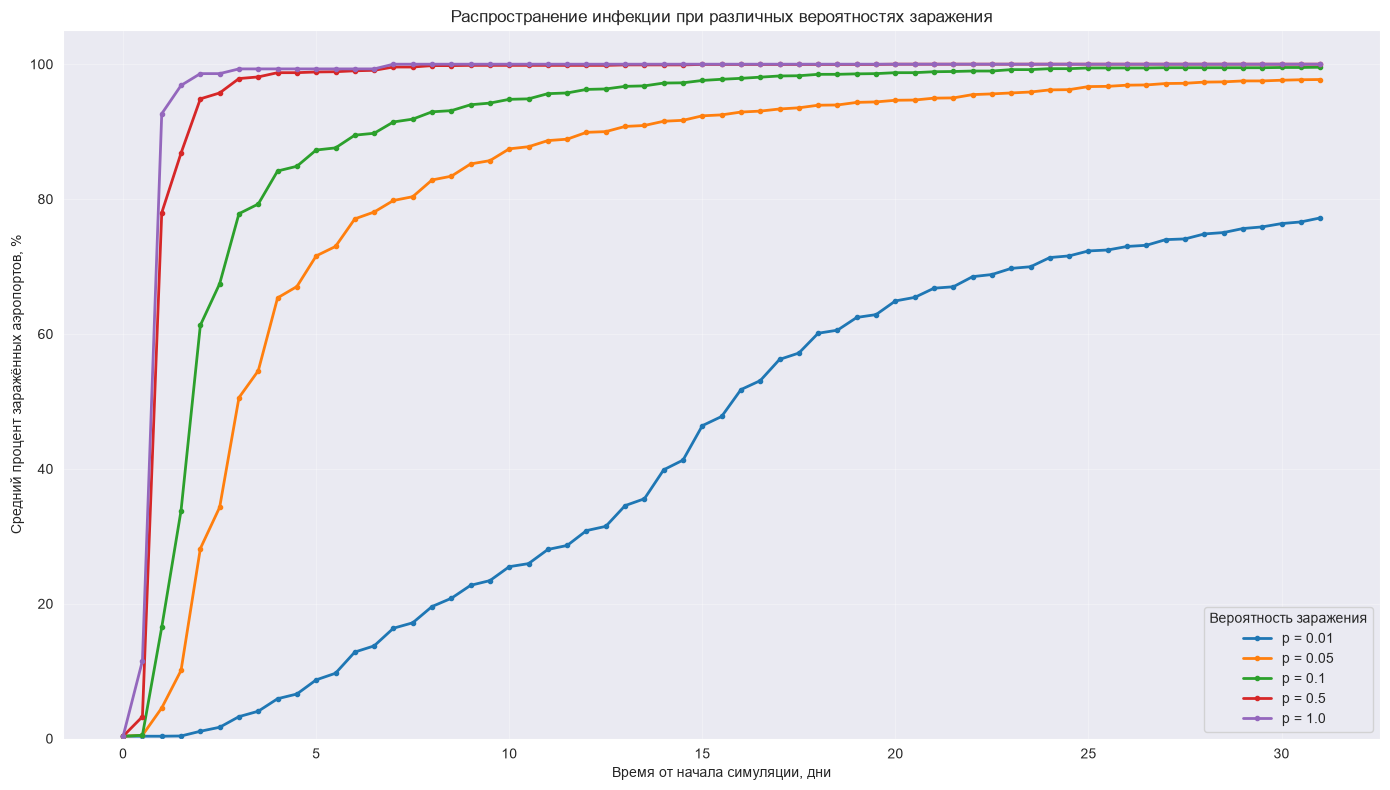

In [28]:
plt.figure(figsize=(14, 8))

for p in infection_probabilities:

    p_data = mean_infection_dynamics[
        mean_infection_dynamics["p"] == p
    ]

    plt.plot(
        p_data["elapsed_hours"] / 24,
        p_data["mean_infected_percent"],
        marker="o",
        markersize=3,
        linewidth=2,
        label=f"p = {p}",
    )

plt.title(
    "Распространение инфекции при различных "
    "вероятностях заражения"
)

plt.xlabel(
    "Время от начала симуляции, дни"
)

plt.ylabel(
    "Средний процент заражённых аэропортов, %"
)

plt.ylim(0, 105)

plt.grid(
    True,
    alpha=0.3,
)

plt.legend(
    title="Вероятность заражения"
)

plt.tight_layout()
plt.show()

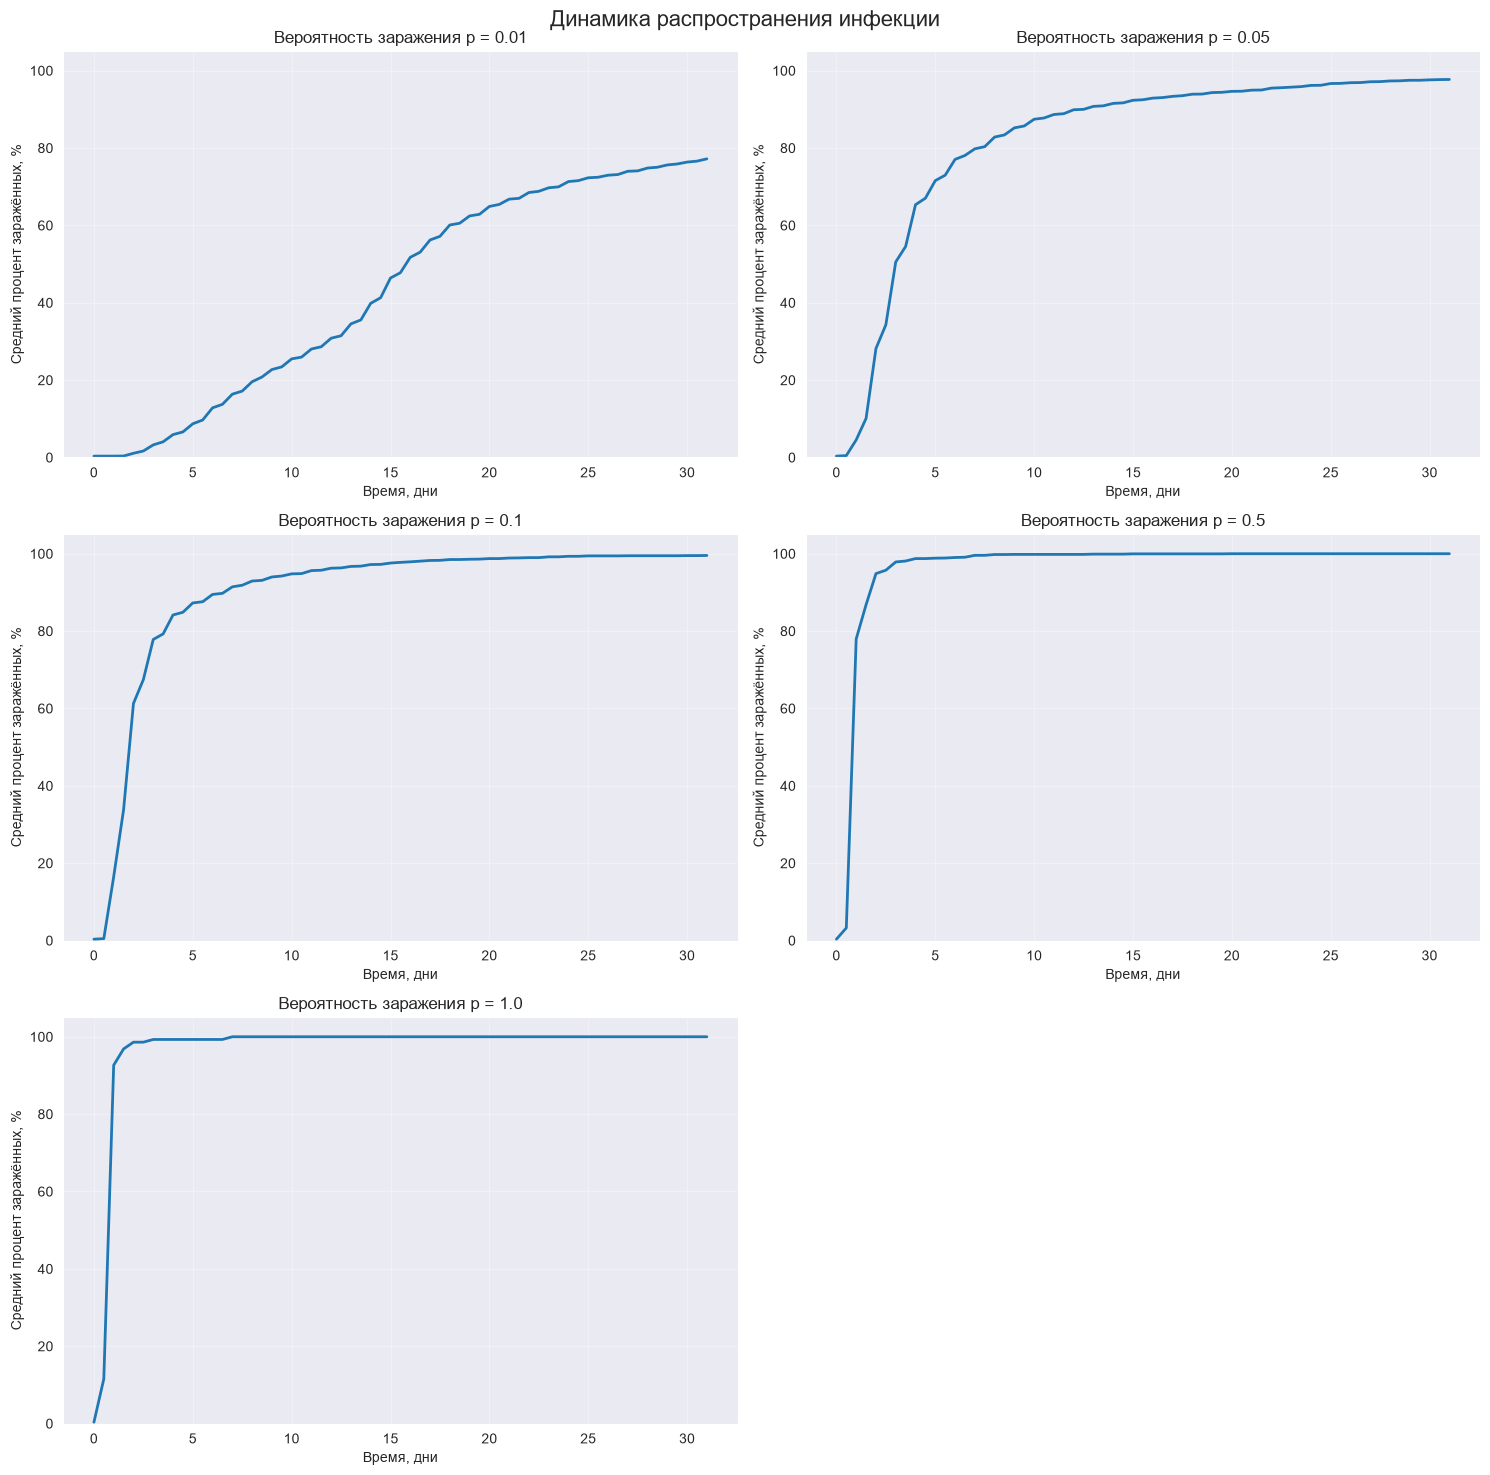

In [29]:
fig, axes = plt.subplots(
    3,
    2,
    figsize=(15, 15),
)

axes = axes.flatten()

for index, p in enumerate(
    infection_probabilities
):

    ax = axes[index]

    p_data = mean_infection_dynamics[
        mean_infection_dynamics["p"] == p
    ]

    ax.plot(
        p_data["elapsed_hours"] / 24,
        p_data["mean_infected_percent"],
        linewidth=2,
    )

    ax.set_title(
        f"Вероятность заражения p = {p}"
    )

    ax.set_xlabel(
        "Время, дни"
    )

    ax.set_ylabel(
        "Средний процент заражённых, %"
    )

    ax.set_ylim(0, 105)

    ax.grid(
        True,
        alpha=0.3,
    )

# Последняя, шестая область нам не нужна.
axes[-1].axis("off")

plt.suptitle(
    "Динамика распространения инфекции",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [30]:
comparison_hours = [
    12,
    24,
    48,
    72,
    168,
    336,
    504,
]

comparison_rows = []

for hours in comparison_hours:

    for p in infection_probabilities:

        p_data = mean_infection_dynamics[
            mean_infection_dynamics["p"] == p
        ].copy()

        closest_index = (
            p_data["elapsed_hours"] - hours
        ).abs().idxmin()

        row = p_data.loc[closest_index]

        comparison_rows.append(
            {
                "hours": hours,
                "days": hours / 24,
                "p": p,
                "mean_infected_percent":
                    row["mean_infected_percent"],
            }
        )

comparison_table = (
    pd.DataFrame(comparison_rows)
    .pivot(
        index="days",
        columns="p",
        values="mean_infected_percent",
    )
)

comparison_table.index.name = "Дни"
comparison_table.columns.name = "p"

print("=" * 70)
print("СРЕДНИЙ ПРОЦЕНТ ЗАРАЖЁННЫХ")
print("=" * 70)

display(
    comparison_table.round(2)
)

СРЕДНИЙ ПРОЦЕНТ ЗАРАЖЁННЫХ


p,0.01,0.05,0.10,0.50,1.00
Дни,,,,,
0.5,0.35,0.49,0.49,3.25,11.54
1.0,0.35,4.55,16.50,77.97,92.66
2.0,1.08,28.18,61.29,94.86,98.60
3.0,3.25,50.56,77.83,97.87,99.30
7.0,16.36,79.79,91.43,99.58,100.00
14.0,39.86,91.54,97.20,99.90,100.00
21.0,66.78,94.97,98.88,100.00,100.00


In [31]:
# Итоговый охват берём непосредственно из результатов полных симуляций.
# Последняя 12-часовая контрольная точка не обязана совпадать с точным
# временем последнего прибытия, поэтому для финального состояния
# корректнее использовать simulation_summary.
final_dynamics = (
    simulation_summary[
        [
            "p",
            "mean_infected",
            "mean_percent",
        ]
    ]
    .rename(
        columns={
            "mean_infected": "mean_infected_count",
            "mean_percent": "mean_infected_percent",
        }
    )
    .sort_values("p")
    .reset_index(drop=True)
)

print("=" * 70)
print("ИТОГОВЫЙ ОХВАТ ЗА ВЕСЬ ПЕРИОД")
print("=" * 70)

display(
    final_dynamics.round(2)
)


ИТОГОВЫЙ ОХВАТ ЗА ВЕСЬ ПЕРИОД


,p,mean_infected_count,mean_infected_percent
0,0.01,221.0,77.27
1,0.05,279.5,97.73
2,0.10,284.7,99.55
3,0.50,286.0,100.00
4,1.00,286.0,100.00


### Вывод по влиянию вероятности заражения

Результаты эксперимента показывают сильную зависимость скорости и итогового масштаба распространения инфекции от вероятности заражения `p`.

При `p = 0.01` распространение происходит сравнительно медленно. В среднем к концу периода заражается 221 из 286 аэропортов, то есть около 77.27%. Через 7 дней заражено в среднем только 16.36% аэропортов, а через 21 день — 66.78%.

При увеличении вероятности до `p = 0.05` распространение существенно ускоряется: через 7 дней заражено уже около 79.79% аэропортов, а к концу периода — 97.73%.

При `p = 0.1` инфекция охватывает сеть ещё быстрее. Уже через 2 дня заражено около 61.29% аэропортов, через 7 дней — 91.43%, а итоговая доля достигает 99.55%.

Для `p = 0.5` и `p = 1.0` во всех 10 симуляциях были заражены все 286 аэропортов. При этом различие между этими вероятностями заметнее всего в первые дни распространения: через сутки при `p = 0.5` заражено в среднем 77.97% аэропортов, тогда как при `p = 1.0` — 92.66%.

Таким образом, увеличение вероятности заражения особенно сильно влияет на начальную скорость распространения инфекции. При высокой связности авиационной сети даже небольшая вероятность передачи инфекции может привести к заражению значительной части аэропортов за достаточно длительный период.

## 4. Часть 3. Анализ сети аэропортов с помощью NetworkX

Построим ненаправленный граф, в котором:

- вершина соответствует аэропорту;
- ребро означает наличие прямых перелётов между двумя аэропортами;
- вес ребра равен относительному количеству рейсов между двумя аэропортами в обоих направлениях.

Если между аэропортами A и B выполнено `n` рейсов, а общее число рейсов в рассматриваемой сети равно `N`, то вес ребра определяется как:

\[
w_{AB} = \frac{n_{AB} + n_{BA}}{N}
\]

После построения графа будут рассчитаны структурные характеристики аэропортов и исследована их связь со временем заражения.

In [32]:
origin_values = flights["Origin"].to_numpy()
dest_values = flights["Dest"].to_numpy()

origin_first = origin_values < dest_values

route_data = pd.DataFrame(
    {
        "airport_a": np.where(
            origin_first,
            origin_values,
            dest_values,
        ),
        "airport_b": np.where(
            origin_first,
            dest_values,
            origin_values,
        ),
    }
)

route_counts = (
    route_data
    .groupby(
        ["airport_a", "airport_b"],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "flight_count",
        }
    )
)

TOTAL_FLIGHTS = len(flights)

route_counts["weight"] = (
    route_counts["flight_count"]
    / TOTAL_FLIGHTS
)

print("=" * 70)
print("НЕНАПРАВЛЕННЫЕ МАРШРУТЫ")
print("=" * 70)

print(
    f"Общее количество рейсов: "
    f"{TOTAL_FLIGHTS:,}"
)

print(
    f"Количество уникальных пар аэропортов: "
    f"{len(route_counts):,}"
)

display(
    route_counts
    .sort_values(
        "flight_count",
        ascending=False,
    )
    .head(15)
)

НЕНАПРАВЛЕННЫЕ МАРШРУТЫ
Общее количество рейсов: 587,130
Количество уникальных пар аэропортов: 2,319


,airport_a,airport_b,flight_count,weight
1457,HNL,OGG,2621,0.004464
1715,LAS,LAX,2194,0.003737
1454,HNL,LIH,2190,0.003730
1793,LAX,SFO,2092,0.003563
1741,LAS,PHX,1948,0.003318
476,BOS,LGA,1902,0.003239
1451,HNL,KOA,1874,0.003192
1783,LAX,PHX,1851,0.003153
1788,LAX,SAN,1839,0.003132
938,DCA,LGA,1794,0.003056


In [33]:
G = nx.Graph()

G.add_nodes_from(airports)

for route in route_counts.itertuples(
    index=False
):
    G.add_edge(
        route.airport_a,
        route.airport_b,
        weight=route.weight,
        flight_count=route.flight_count,
    )

print("=" * 70)
print("ГРАФ АЭРОПОРТОВ")
print("=" * 70)

print(
    f"Количество вершин: "
    f"{G.number_of_nodes()}"
)

print(
    f"Количество рёбер: "
    f"{G.number_of_edges()}"
)

print(
    f"Граф связный: "
    f"{nx.is_connected(G)}"
)

print(
    f"Количество компонент связности: "
    f"{nx.number_connected_components(G)}"
)

total_edge_weight = sum(
    data["weight"]
    for _, _, data in G.edges(data=True)
)

print(
    f"Сумма весов всех рёбер: "
    f"{total_edge_weight:.6f}"
)

ГРАФ АЭРОПОРТОВ
Количество вершин: 286
Количество рёбер: 2319
Граф связный: True
Количество компонент связности: 1
Сумма весов всех рёбер: 1.000000


In [34]:
degrees = dict(G.degree())

print("=" * 70)
print("ОСНОВНЫЕ ХАРАКТЕРИСТИКИ ГРАФА")
print("=" * 70)

print(
    f"Средняя степень вершины: "
    f"{np.mean(list(degrees.values())):.2f}"
)

print(
    f"Минимальная степень: "
    f"{min(degrees.values())}"
)

print(
    f"Максимальная степень: "
    f"{max(degrees.values())}"
)

print("\n10 аэропортов с максимальной степенью:")

top_degree = sorted(
    degrees.items(),
    key=lambda item: item[1],
    reverse=True,
)[:10]

for airport, degree in top_degree:
    print(
        f"{airport}: {degree}"
    )

ОСНОВНЫЕ ХАРАКТЕРИСТИКИ ГРАФА
Средняя степень вершины: 16.22
Минимальная степень: 1
Максимальная степень: 166

10 аэропортов с максимальной степенью:
ATL: 166
ORD: 142
DFW: 130
DEN: 113
DTW: 111
IAH: 110
MSP: 110
SLC: 103
CVG: 96
LAS: 90


### 50 симуляций при p = 0.5

Для оценки типичного времени заражения каждого аэропорта выполняются 50 независимых SI-симуляций с вероятностью заражения `p = 0.5`.

Для каждого аэропорта затем будет рассчитано медианное время от начала симуляции до момента его заражения.

Если в отдельной симуляции аэропорт не успел заразиться до завершения рассматриваемого периода, для него в этой симуляции время заражения отсутствует. Медиана рассчитывается по наблюдаемым временам заражения, а столбец `infected_runs` дополнительно показывает, в скольких из 50 симуляций аэропорт был заражён.


In [35]:
N_NETWORK_SIMULATIONS = 50
NETWORK_P = 0.5

network_simulations = []

start = perf_counter()

for run in range(
    N_NETWORK_SIMULATIONS
):
    result = simulate_infection(
        start_airport=START_AIRPORT,
        p=NETWORK_P,
        seed=10_000 + RANDOM_STATE + run,
    )

    network_simulations.append(result)

    print(
        f"Симуляция "
        f"{run + 1:02d}/{N_NETWORK_SIMULATIONS}: "
        f"{len(result)}/{len(airports)} аэропортов"
    )

elapsed = perf_counter() - start

print("=" * 70)
print("50 СИМУЛЯЦИЙ ЗАВЕРШЕНЫ")
print("=" * 70)

print(
    f"Время выполнения: "
    f"{elapsed:.2f} сек."
)

infected_counts_50 = [
    len(result)
    for result in network_simulations
]

print(
    f"Минимальное число заражённых: "
    f"{min(infected_counts_50)}"
)

print(
    f"Максимальное число заражённых: "
    f"{max(infected_counts_50)}"
)

print(
    f"Среднее число заражённых: "
    f"{np.mean(infected_counts_50):.2f}"
)

Симуляция 01/50: 286/286 аэропортов
Симуляция 02/50: 286/286 аэропортов
Симуляция 03/50: 286/286 аэропортов
Симуляция 04/50: 286/286 аэропортов
Симуляция 05/50: 286/286 аэропортов
Симуляция 06/50: 286/286 аэропортов
Симуляция 07/50: 286/286 аэропортов
Симуляция 08/50: 286/286 аэропортов
Симуляция 09/50: 286/286 аэропортов
Симуляция 10/50: 285/286 аэропортов
Симуляция 11/50: 286/286 аэропортов
Симуляция 12/50: 286/286 аэропортов
Симуляция 13/50: 286/286 аэропортов
Симуляция 14/50: 286/286 аэропортов
Симуляция 15/50: 286/286 аэропортов
Симуляция 16/50: 286/286 аэропортов
Симуляция 17/50: 286/286 аэропортов
Симуляция 18/50: 286/286 аэропортов
Симуляция 19/50: 286/286 аэропортов
Симуляция 20/50: 286/286 аэропортов
Симуляция 21/50: 286/286 аэропортов
Симуляция 22/50: 286/286 аэропортов
Симуляция 23/50: 286/286 аэропортов
Симуляция 24/50: 286/286 аэропортов
Симуляция 25/50: 286/286 аэропортов
Симуляция 26/50: 286/286 аэропортов
Симуляция 27/50: 286/286 аэропортов
Симуляция 28/50: 286/286 аэр

In [36]:
infection_records = []

for run_number, result in enumerate(
    network_simulations,
    start=1,
):

    for infection_time, airport in result.items():

        elapsed_hours = (
            infection_time
            - simulation_start_time
        ).total_seconds() / 3600

        infection_records.append(
            {
                "run": run_number,
                "airport": airport,
                "infection_time": infection_time,
                "infection_hours": elapsed_hours,
            }
        )

infection_times_50 = pd.DataFrame(
    infection_records
)

print("=" * 70)
print("ВРЕМЕНА ЗАРАЖЕНИЯ")
print("=" * 70)

print(
    f"Количество записей: "
    f"{len(infection_times_50):,}"
)

display(
    infection_times_50.head(10)
)

ВРЕМЕНА ЗАРАЖЕНИЯ
Количество записей: 14,298


,run,airport,infection_time,infection_hours
0,1,ABE,2008-01-01 00:01:00,0.000000
1,1,ORD,2008-01-01 10:17:00,10.266667
2,1,MCI,2008-01-01 11:41:00,11.666667
3,1,DAY,2008-01-01 11:55:00,11.900000
4,1,MKE,2008-01-01 12:04:00,12.050000
5,1,FNT,2008-01-01 12:16:00,12.250000
6,1,LAN,2008-01-01 12:18:00,12.283333
7,1,IND,2008-01-01 12:23:00,12.366667
8,1,DTW,2008-01-01 12:25:00,12.400000
9,1,GRR,2008-01-01 12:30:00,12.483333


In [37]:
median_infection_times = (
    infection_times_50
    .groupby(
        "airport",
        as_index=False,
    )
    .agg(
        median_infection_hours=(
            "infection_hours",
            "median",
        ),
        infected_runs=(
            "run",
            "nunique",
        ),
    )
)

median_infection_times[
    "median_infection_days"
] = (
    median_infection_times[
        "median_infection_hours"
    ]
    / 24
)

print("=" * 70)
print("МЕДИАННОЕ ВРЕМЯ ЗАРАЖЕНИЯ")
print("=" * 70)

print(
    f"Аэропортов: "
    f"{len(median_infection_times)}"
)

print(
    f"Минимальное число симуляций, "
    f"в которых заразился аэропорт: "
    f"{median_infection_times['infected_runs'].min()}"
)

display(
    median_infection_times
    .sort_values(
        "median_infection_hours"
    )
    .head(15)
)

МЕДИАННОЕ ВРЕМЯ ЗАРАЖЕНИЯ
Аэропортов: 286
Минимальное число симуляций, в которых заразился аэропорт: 49


,airport,median_infection_hours,infected_runs,median_infection_days
0,ABE,0.000000,50,0.000000
83,DTW,10.241667,50,0.426736
198,ORD,10.508333,50,0.437847
60,CLT,11.000000,50,0.458333
176,MKE,12.050000,50,0.502083
133,IND,12.366667,50,0.515278
114,GRR,12.483333,50,0.520139
45,BWI,12.516667,50,0.521528
70,CVG,12.591667,50,0.524653
206,PHL,12.633333,50,0.526389


In [38]:
print("=" * 70)
print("15 АЭРОПОРТОВ С НАИБОЛЬШИМ МЕДИАННЫМ ВРЕМЕНЕМ")
print("=" * 70)

display(
    median_infection_times
    .sort_values(
        "median_infection_hours",
        ascending=False,
    )
    .head(15)
)

15 АЭРОПОРТОВ С НАИБОЛЬШИМ МЕДИАННЫМ ВРЕМЕНЕМ


,airport,median_infection_hours,infected_runs,median_infection_days
211,PLN,167.466667,50,6.977778
49,CDC,158.466667,50,6.602778
7,ADK,137.433333,49,5.726389
12,ALO,71.566667,50,2.981944
225,RHI,64.900000,50,2.704167
283,YAK,59.800000,50,2.491667
281,WRG,57.333333,50,2.388889
30,BLI,47.383333,50,1.974306
63,CMX,47.266667,50,1.969444
247,SIT,46.783333,50,1.949306


### Расчёт структурных характеристик аэропортов

Для каждой вершины графа рассчитываются три характеристики:

- **коэффициент кластеризации (`clustering`)** — показывает, насколько хорошо между собой связаны соседи аэропорта;
- **степень вершины (`degree`)** — количество аэропортов, с которыми существует прямое авиасообщение;
- **центральность по посредничеству (`betweenness centrality`)** — характеризует, насколько часто вершина лежит на кратчайших путях между другими вершинами сети.

Для соответствия условию используются стандартные функции NetworkX. Вес ребра при этом хранит относительную интенсивность авиасообщения, а перечисленные структурные метрики рассчитываются по топологии сети.

Параметр `weight` не передаётся в `betweenness_centrality`, потому что в данном графе большой вес означает более интенсивное авиасообщение, тогда как NetworkX при поиске кратчайших путей интерпретирует вес как длину/стоимость ребра. Поэтому требуемые метрики рассчитываются по топологии графа.

Стартовый аэропорт `ABE` имеет время заражения, равное нулю по определению модели, а не вследствие своей позиции в сети. Поэтому его сетевые метрики сохраняются в общей таблице, но при построении scatter-plot-ов и расчёте корреляций Спирмена `ABE` исключается, чтобы искусственно заданное нулевое время не искажало оценку связи.


In [39]:
clustering = nx.clustering(G)

degree = dict(
    G.degree()
)

betweenness = (
    nx.betweenness_centrality(
        G,
        normalized=True,
    )
)

network_metrics = pd.DataFrame(
    {
        "airport": airports,
        "clustering": [
            clustering[airport]
            for airport in airports
        ],
        "degree": [
            degree[airport]
            for airport in airports
        ],
        "betweenness": [
            betweenness[airport]
            for airport in airports
        ],
    }
)

print("=" * 70)
print("СЕТЕВЫЕ МЕТРИКИ")
print("=" * 70)

display(
    network_metrics.head(10)
)

print("\nОписательная статистика:")

display(
    network_metrics[
        [
            "clustering",
            "degree",
            "betweenness",
        ]
    ].describe()
)

СЕТЕВЫЕ МЕТРИКИ


,airport,clustering,degree,betweenness
0,ABE,1.000000,7,0.000000
1,ABI,0.000000,1,0.000000
2,ABQ,0.671171,37,0.002480
3,ABY,0.000000,1,0.000000
4,ACT,0.000000,1,0.000000
5,ACV,0.666667,3,0.000019
6,ACY,1.000000,2,0.000000
7,ADK,0.000000,1,0.000000
8,ADQ,0.000000,1,0.000000
9,AEX,1.000000,3,0.000000



Описательная статистика:


,clustering,degree,betweenness
count,286.000000,286.000000,286.000000
mean,0.643969,16.216783,0.004709
std,0.402992,26.179043,0.020847
min,0.000000,1.000000,0.000000
25%,0.229764,2.000000,0.000000
50%,0.826118,5.000000,0.000000
75%,1.000000,17.000000,0.000129
max,1.000000,166.000000,0.231581


In [40]:
airport_analysis = (
    median_infection_times
    .merge(
        network_metrics,
        on="airport",
        how="left",
    )
)

print("=" * 70)
print("ИТОГОВАЯ ТАБЛИЦА АЭРОПОРТОВ")
print("=" * 70)

print(
    f"Количество аэропортов: "
    f"{len(airport_analysis)}"
)

print("\nПропуски:")

display(
    airport_analysis
    .isna()
    .sum()
    .to_frame("missing")
)

display(
    airport_analysis
    .sort_values(
        "median_infection_hours"
    )
    .head(15)
)

ИТОГОВАЯ ТАБЛИЦА АЭРОПОРТОВ
Количество аэропортов: 286

Пропуски:


,missing
airport,0
median_infection_hours,0
infected_runs,0
median_infection_days,0
clustering,0
degree,0
betweenness,0


,airport,median_infection_hours,infected_runs,median_infection_days,clustering,degree,betweenness
0,ABE,0.000000,50,0.000000,1.000000,7,0.000000e+00
83,DTW,10.241667,50,0.426736,0.219984,111,7.047379e-02
198,ORD,10.508333,50,0.437847,0.170313,142,1.063752e-01
60,CLT,11.000000,50,0.458333,0.450128,69,1.042631e-02
176,MKE,12.050000,50,0.502083,0.809117,27,1.553552e-03
133,IND,12.366667,50,0.515278,0.858871,32,2.630940e-04
114,GRR,12.483333,50,0.520139,0.989011,14,5.491036e-07
45,BWI,12.516667,50,0.521528,0.558738,59,2.892500e-03
70,CVG,12.591667,50,0.524653,0.288158,96,2.441708e-02
206,PHL,12.633333,50,0.526389,0.639184,50,1.786806e-03


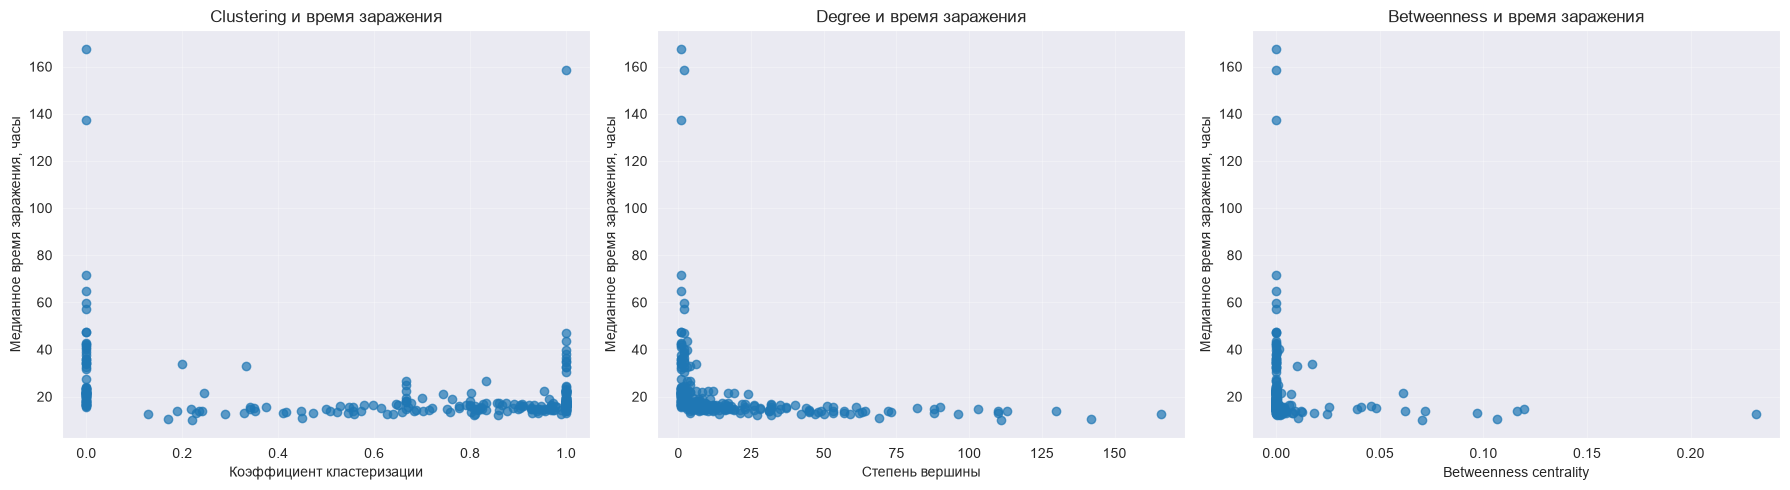

In [41]:
correlation_data = airport_analysis[
    airport_analysis["airport"]
    != START_AIRPORT
].copy()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)

axes[0].scatter(
    correlation_data["clustering"],
    correlation_data["median_infection_hours"],
    alpha=0.7,
)

axes[0].set_title(
    "Clustering и время заражения"
)
axes[0].set_xlabel(
    "Коэффициент кластеризации"
)
axes[0].set_ylabel(
    "Медианное время заражения, часы"
)
axes[0].grid(
    True,
    alpha=0.3,
)

axes[1].scatter(
    correlation_data["degree"],
    correlation_data["median_infection_hours"],
    alpha=0.7,
)

axes[1].set_title(
    "Degree и время заражения"
)
axes[1].set_xlabel(
    "Степень вершины"
)
axes[1].set_ylabel(
    "Медианное время заражения, часы"
)
axes[1].grid(
    True,
    alpha=0.3,
)

axes[2].scatter(
    correlation_data["betweenness"],
    correlation_data["median_infection_hours"],
    alpha=0.7,
)

axes[2].set_title(
    "Betweenness и время заражения"
)
axes[2].set_xlabel(
    "Betweenness centrality"
)
axes[2].set_ylabel(
    "Медианное время заражения, часы"
)
axes[2].grid(
    True,
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [42]:
correlation_rows = []

metrics = [
    "clustering",
    "degree",
    "betweenness",
]

for metric in metrics:

    rho, p_value = spearmanr(
        correlation_data[metric],
        correlation_data[
            "median_infection_hours"
        ],
    )

    correlation_rows.append(
        {
            "metric": metric,
            "spearman_rho": rho,
            "p_value": p_value,
            "abs_correlation": abs(rho),
        }
    )

spearman_results = (
    pd.DataFrame(correlation_rows)
    .sort_values(
        "abs_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("КОРРЕЛЯЦИЯ СПИРМЕНА")
print("=" * 70)

display(
    spearman_results.round(6)
)

КОРРЕЛЯЦИЯ СПИРМЕНА


,metric,spearman_rho,p_value,abs_correlation
0,degree,-0.775562,0.000000,0.775562
1,betweenness,-0.580051,0.000000,0.580051
2,clustering,-0.124566,0.035565,0.124566


In [43]:
strongest_metric = (
    spearman_results.iloc[0]
)

print("=" * 70)
print("СИЛЬНЕЙШАЯ СВЯЗЬ")
print("=" * 70)

print(
    f"Метрика: "
    f"{strongest_metric['metric']}"
)

print(
    f"Spearman rho: "
    f"{strongest_metric['spearman_rho']:.4f}"
)

print(
    f"|rho|: "
    f"{strongest_metric['abs_correlation']:.4f}"
)

print(
    f"p-value: "
    f"{strongest_metric['p_value']:.6g}"
)

СИЛЬНЕЙШАЯ СВЯЗЬ
Метрика: degree
Spearman rho: -0.7756
|rho|: 0.7756
p-value: 1.76257e-58


### Вывод по анализу сетевых характеристик

Построенный граф аэропортов содержит 286 вершин и 2319 рёбер и является связным. Средняя степень вершины составляет 16.22, при этом наиболее связанным аэропортом является ATL со степенью 166.

В 50 симуляциях при вероятности заражения `p = 0.5` почти во всех случаях инфекция распространилась на всю сеть: в 48 симуляциях были заражены все 286 аэропортов, а в двух симуляциях — 285 аэропортов.

Корреляционный анализ Спирмена показал, что наиболее сильная связь наблюдается между степенью вершины (`degree`) и медианным временем заражения:

- `degree`: ρ = -0.776;
- `betweenness centrality`: ρ = -0.580;
- `clustering`: ρ = -0.125.

Наиболее сильная по модулю корреляция наблюдается для степени вершины. Отрицательный знак означает, что аэропорты с большим количеством прямых связей с другими аэропортами в среднем заражаются раньше.

Это объясняется тем, что высокосвязанные аэропорты имеют больше входящих и исходящих маршрутов и, следовательно, больше возможностей получить инфекцию через один из рейсов. Центральность по посредничеству также отрицательно связана со временем заражения: аэропорты, занимающие важное положение на путях между другими частями сети, обычно заражаются раньше.

Коэффициент кластеризации имеет значительно более слабую связь со временем заражения. Высокая локальная связанность соседей сама по себе не гарантирует раннего заражения аэропорта, поскольку для распространения инфекции важнее количество доступных связей с различными участками сети.

В двух из 50 прогонов один аэропорт не успел заразиться к концу периода, поэтому для таких редких случаев медианное время рассчитывалось по тем симуляциям, где заражение произошло; число доступных наблюдений контролируется через `infected_runs`.

При корреляционном анализе стартовый `ABE` исключён, поскольку его нулевое время заражения задано условием эксперимента и не является следствием сетевой структуры.


## 5. Общий вывод

В работе была реализована SI-модель распространения инфекции по сети авиаперелётов США за январь 2008 года.

Эксперименты показали, что вероятность передачи инфекции существенно влияет прежде всего на скорость её распространения. При низкой вероятности `p = 0.01` к концу периода в среднем заражалось около 77% аэропортов, тогда как при `p = 0.5` и `p = 1.0` инфекция практически гарантированно охватывала всю сеть.

Анализ сети с помощью NetworkX показал, что структура авиационных связей позволяет частично предсказывать скорость заражения отдельных аэропортов. Наиболее информативной характеристикой оказалась степень вершины: коэффициент корреляции Спирмена между degree и медианным временем заражения составил примерно -0.776.

Следовательно, аэропорты с большим количеством прямых связей являются наиболее уязвимыми для быстрого распространения инфекции. Полученные результаты показывают, что при моделировании эпидемий важны не только свойства самой инфекции, но и структура транспортной сети, по которой она распространяется.